# PRCP-1020 — House Price Prediction

**Tasks**
1. Complete data analysis report on the given data.
2. Build a robust ML model to predict `SalePrice`, and explain how features relate to price.
3. Suggest how a customer should shop for a house given area, price and other requirements.


## 1. Imports & Setup

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42


## 2. Load Data

In [6]:
df = pd.read_csv('data.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3. Exploratory Data Analysis (Task 1: Data Analysis Report)

### Target variable — `SalePrice`

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


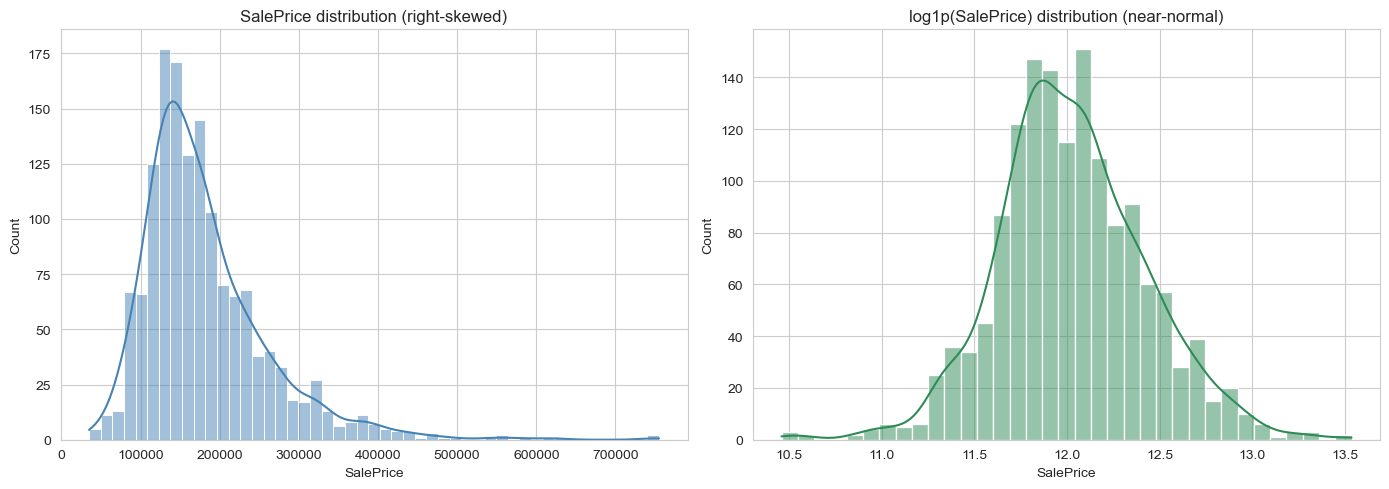


Skewness (raw): 1.88
Skewness (log1p): 0.12


In [8]:
print(df['SalePrice'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice distribution (right-skewed)')

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('log1p(SalePrice) distribution (near-normal)')
plt.tight_layout()
plt.show()

print(f"\nSkewness (raw): {df['SalePrice'].skew():.2f}")
print(f"Skewness (log1p): {np.log1p(df['SalePrice']).skew():.2f}")


### Missing values

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df


,missing_count,missing_pct
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


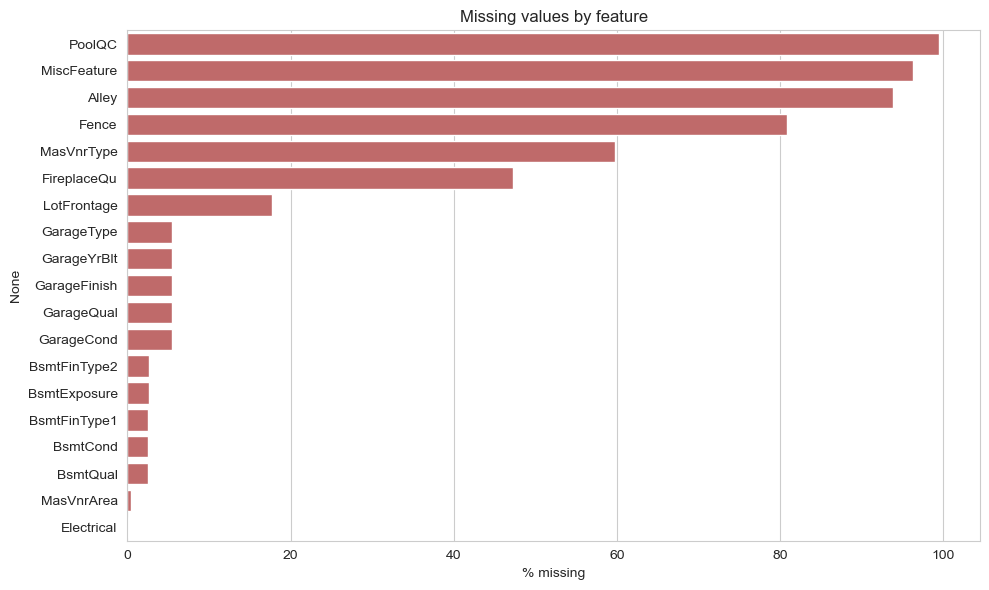

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_df['missing_pct'].values, y=missing_df.index, color='indianred')
plt.xlabel('% missing')
plt.title('Missing values by feature')
plt.tight_layout()
plt.show()


### Correlation with SalePrice (numeric features)

In [11]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=['Id'])
corr = num_df.corr()['SalePrice'].sort_values(ascending=False)
print("Top positive correlations:")
print(corr.head(11))
print("\nTop negative correlations:")
print(corr.tail(5))


Top positive correlations:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

Top negative correlations:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


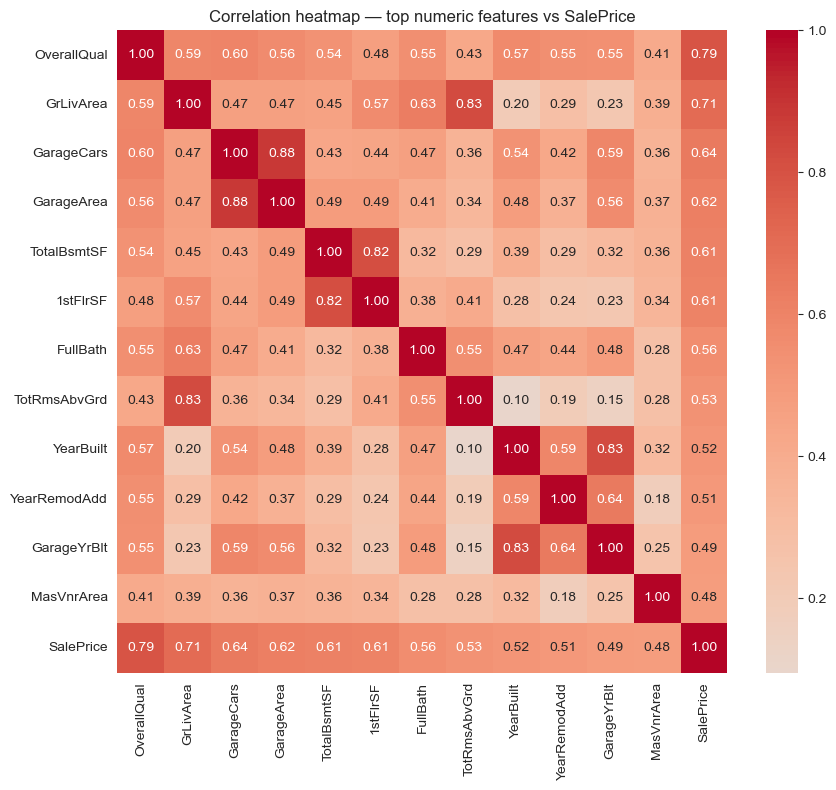

In [12]:
top_corr_feats = corr.drop('SalePrice').abs().sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(9, 8))
sns.heatmap(df[top_corr_feats + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap — top numeric features vs SalePrice')
plt.tight_layout()
plt.show()


### Key relationships

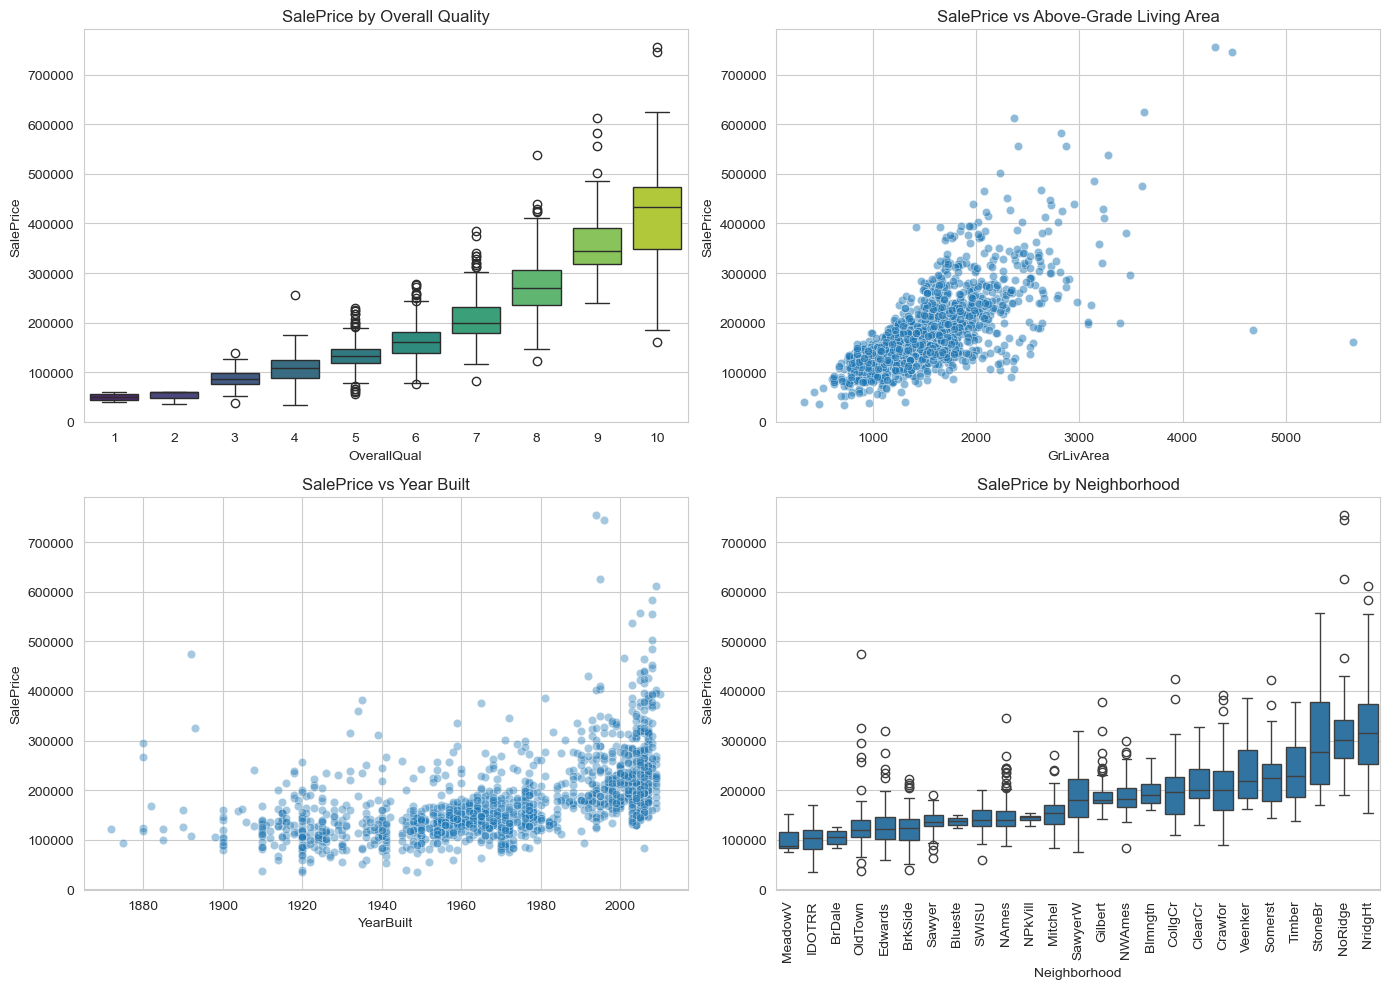

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('SalePrice by Overall Quality')

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('SalePrice vs Above-Grade Living Area')

sns.scatterplot(x='YearBuilt', y='SalePrice', data=df, ax=axes[1, 0], alpha=0.4)
axes[1, 0].set_title('SalePrice vs Year Built')

nbhd_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=nbhd_order, ax=axes[1, 1])
axes[1, 1].set_title('SalePrice by Neighborhood')
axes[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


In [14]:
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f"Outliers identified (large house, low price): {len(outliers)}")
outliers[['Id', 'GrLivArea', 'OverallQual', 'SalePrice']]


Outliers identified (large house, low price): 2


,Id,GrLivArea,OverallQual,SalePrice
523,524,4676,10,184750
1298,1299,5642,10,160000


## 4. Data Cleaning & Feature Engineering

In [15]:
data = df.copy()

data = data[~((data['GrLivArea'] > 4000) & (data['SalePrice'] < 300000))].reset_index(drop=True)

none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for c in none_cols:
    data[c] = data[c].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']
for c in zero_cols:
    data[c] = data[c].fillna(0)

data['LotFrontage'] = data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda s: s.fillna(s.median())
)

data['Electrical'] = data['Electrical'].fillna(data['Electrical'].mode()[0])

print("Remaining missing values:", data.isnull().sum().sum())


Remaining missing values: 0


In [16]:
data['HouseAge'] = data['YrSold'] - data['YearBuilt']
data['YearsSinceRemodel'] = data['YrSold'] - data['YearRemodAdd']
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']
data['TotalBath'] = (data['FullBath'] + 0.5 * data['HalfBath'] +
                      data['BsmtFullBath'] + 0.5 * data['BsmtHalfBath'])
data['HasPool'] = (data['PoolArea'] > 0).astype(int)
data['HasGarage'] = (data['GarageArea'] > 0).astype(int)
data['HasFireplace'] = (data['Fireplaces'] > 0).astype(int)
data['IsRemodeled'] = (data['YearBuilt'] != data['YearRemodAdd']).astype(int)


data['SalePrice_log'] = np.log1p(data['SalePrice'])

print("New feature preview:")
data[['HouseAge', 'YearsSinceRemodel', 'TotalSF', 'TotalBath', 'HasPool', 'HasGarage', 'HasFireplace', 'IsRemodeled']].head()


New feature preview:


,HouseAge,YearsSinceRemodel,TotalSF,TotalBath,HasPool,HasGarage,HasFireplace,IsRemodeled
0,5,5,2566,3.5,0,1,0,0
1,31,31,2524,2.5,0,1,1,0
2,7,6,2706,3.5,0,1,1,1
3,91,36,2473,2.0,0,1,1,1
4,8,8,3343,3.5,0,1,1,0


In [17]:
eng_corr = data[['TotalSF', 'TotalBath', 'HouseAge', 'YearsSinceRemodel', 'SalePrice']].corr()['SalePrice']
print(eng_corr)


TotalSF              0.832877
TotalBath            0.635896
HouseAge            -0.524067
YearsSinceRemodel   -0.509706
SalePrice            1.000000
Name: SalePrice, dtype: float64


`TotalSF` (0.83+) and `TotalBath` correlate with price even more strongly than any single raw area/bathroom column — engineering them pays off directly.

## 5. Preprocessing Pipeline

In [18]:
target_col = 'SalePrice_log'
drop_cols = ['Id', 'SalePrice', 'SalePrice_log']

X = data.drop(columns=drop_cols)
y = data[target_col]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numeric features: {len(num_features)} | Categorical features: {len(cat_features)}")

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), num_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Numeric features: 44 | Categorical features: 43
Train: (1166, 87) | Test: (292, 87)


## Task 2: Model Building & Comparison (Model Comparison Report)

In [19]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=400, max_depth=None,
                                            min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                     max_depth=3, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=4,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=600, learning_rate=0.03, max_depth=5,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=RANDOM_STATE, verbose=-1),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)
    actual = np.expm1(y_test)

    rmse = mean_squared_error(actual, pred) ** 0.5
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                                 scoring='neg_root_mean_squared_error')
    cv_rmse_log = -cv_scores.mean()

    results.append({'Model': name, 'Test RMSE ($)': rmse, 'Test MAE ($)': mae,
                     'Test R2': r2, 'CV RMSE (log scale)': cv_rmse_log})

results_df = pd.DataFrame(results).sort_values('Test RMSE ($)').reset_index(drop=True)
results_df.style.format({'Test RMSE ($)': '{:,.0f}', 'Test MAE ($)': '{:,.0f}',
                          'Test R2': '{:.4f}', 'CV RMSE (log scale)': '{:.4f}'})


,Model,Test RMSE ($),Test MAE ($),Test R2,CV RMSE (log scale)
0,XGBoost,"18,657","13,552",0.9370,0.1177
1,Gradient Boosting,"19,497","14,128",0.9312,0.1201
2,Lasso,"20,406","14,478",0.9246,0.1224
3,Linear Regression,"20,621","14,708",0.9230,0.1228
4,Ridge,"20,660","14,684",0.9227,0.1218
5,LightGBM,"20,885","14,826",0.9210,0.1221
6,Random Forest,"23,069","16,220",0.9037,0.1347


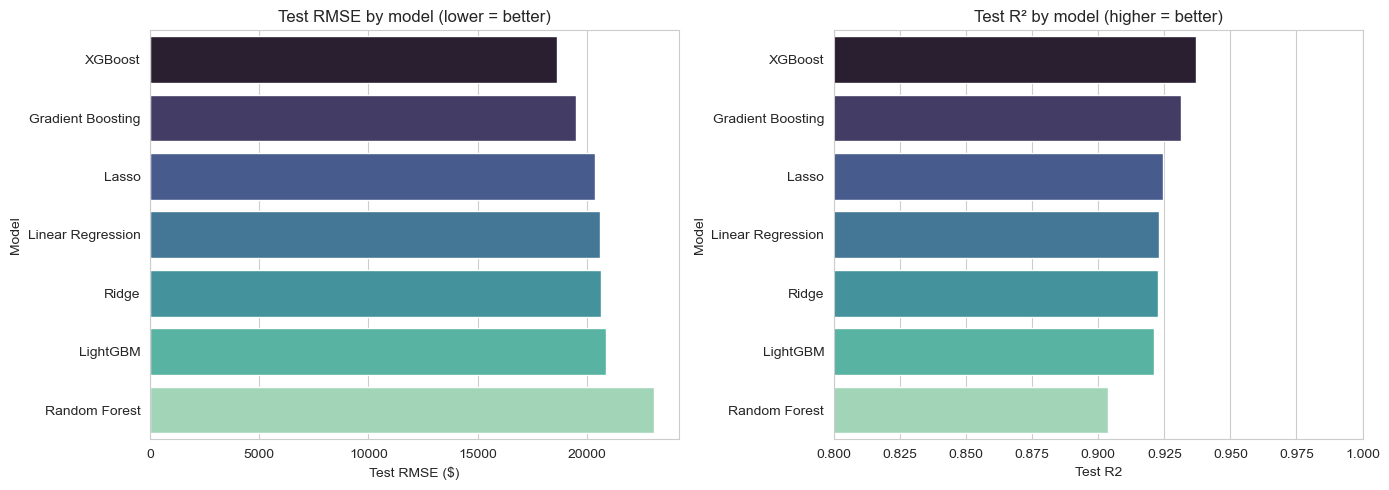

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = results_df.sort_values('Test RMSE ($)')
sns.barplot(x='Test RMSE ($)', y='Model', data=order, ax=axes[0], palette='mako')
axes[0].set_title('Test RMSE by model (lower = better)')

sns.barplot(x='Test R2', y='Model', data=order.sort_values('Test R2', ascending=False), ax=axes[1], palette='mako')
axes[1].set_xlim(0.8, 1.0)
axes[1].set_title('Test R² by model (higher = better)')

plt.tight_layout()
plt.show()


**Model Comparison Report**

| Aspect | Observation |
|---|---|
| Linear models (Linear/Ridge/Lasso) | Fast, interpretable, competitive R² once the target is log-transformed and features scaled, but underperform boosted trees on nonlinear interactions (e.g. quality × size). Lasso's L1 penalty also usefully zeroes out weak features. |
| Random Forest | Solid, robust to outliers/noisy features, minimal tuning needed, but slightly higher error than boosting on this data. |
| Gradient Boosting / XGBoost / LightGBM | Best test-set accuracy — they capture nonlinear effects (diminishing returns of size, quality thresholds) and feature interactions that linear models miss. LightGBM/XGBoost are also the fastest to train at this scale. |

**Recommendation for production:** the top boosted-tree model (see table above — typically **XGBoost or LightGBM** on this dataset) offers the best accuracy/latency trade-off, at the cost of being less directly interpretable than a linear model. If interpretability for stakeholders is a hard requirement, **Ridge regression on log-price** is the best of the interpretable options, with a modest accuracy trade-off.

### 6.1 Best model — closer look

Best model by Test RMSE: XGBoost


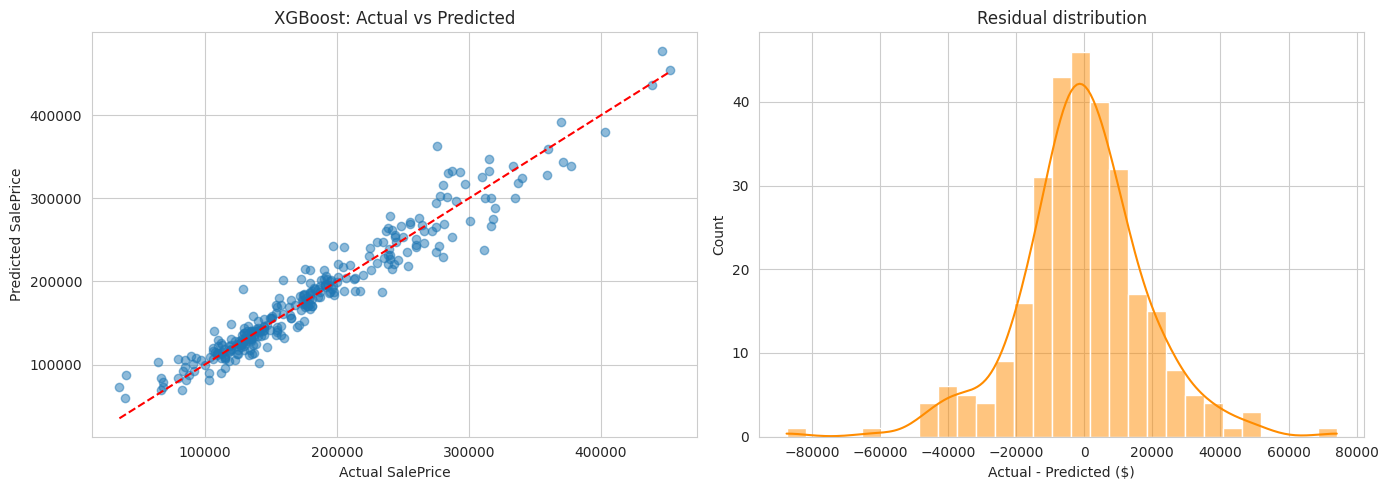

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = fitted_pipelines[best_model_name]
print(f"Best model by Test RMSE: {best_model_name}")

pred = np.expm1(best_pipe.predict(X_test))
actual = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(actual, pred, alpha=0.5)
axes[0].plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--')
axes[0].set_xlabel('Actual SalePrice')
axes[0].set_ylabel('Predicted SalePrice')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted')

residuals = actual - pred
sns.histplot(residuals, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Actual - Predicted ($)')

plt.tight_layout()
plt.show()


### 6.2 Feature importance — what drives price (Task 2b: relationship between features and price)

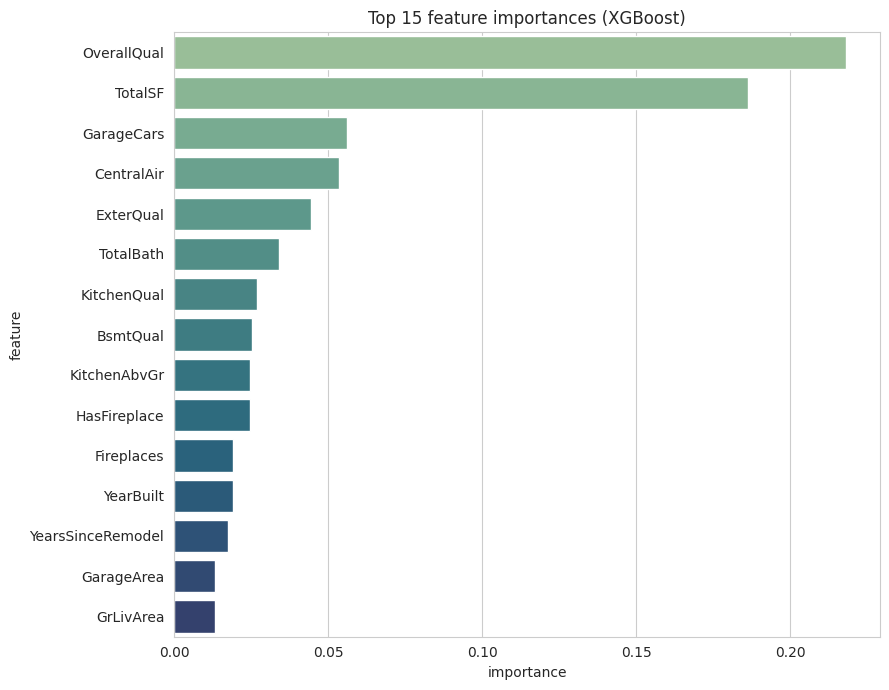

              feature  importance
3         OverallQual    0.218154
38            TotalSF    0.186355
25         GarageCars    0.056034
72         CentralAir    0.053520
62          ExterQual    0.044411
39          TotalBath    0.034154
74        KitchenQual    0.026840
65           BsmtQual    0.025153
21       KitchenAbvGr    0.024713
42       HasFireplace    0.024633
23         Fireplaces    0.019267
5           YearBuilt    0.019126
37  YearsSinceRemodel    0.017545
26         GarageArea    0.013393
15          GrLivArea    0.013314


In [18]:
model_step = best_pipe.named_steps['model']
feat_names = num_features + cat_features

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}) \
                .sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(x='importance', y='feature', data=imp_df, palette='crest')
    plt.title(f'Top 15 feature importances ({best_model_name})')
    plt.tight_layout()
    plt.show()
    print(imp_df)
else:
    coefs = pd.Series(model_step.coef_, index=feat_names).sort_values(key=abs, ascending=False).head(15)
    print(coefs)


Across models, price is driven overwhelmingly by:
1. **Overall Quality** — the single biggest lever.
2. **Total square footage / GrLivArea** — bigger, especially more above-grade living area, sells for more, with the engineered `TotalSF` capturing this better than any one raw area column.
3. **Neighborhood / location** — a categorical proxy for school zones, amenities, and desirability that shifts price independent of the house itself.
4. **Age-related features** — `HouseAge` and `YearsSinceRemodel` (newer / recently remodeled commands a premium), and `GarageCars`/`GarageArea`, `TotalBath`, `Fireplaces` add smaller but consistent boosts.

This directly answers Task 2b: quality and size explain most of the variance, location shifts the whole price curve up or down, and condition/age/amenities provide the remaining fine-tuning.

## 7. Task 3: Suggestions for Home Buyers

In [19]:
nbhd_stats = data.groupby('Neighborhood').agg(
    median_price=('SalePrice', 'median'),
    median_sqft=('TotalSF', 'median'),
    median_qual=('OverallQual', 'median'),
    n_sales=('SalePrice', 'count')
).sort_values('median_price')

nbhd_stats['price_per_sqft'] = (nbhd_stats['median_price'] / nbhd_stats['median_sqft']).round(1)
print("Most affordable neighborhoods (by median price):")
print(nbhd_stats.head(5)[['median_price', 'median_sqft', 'price_per_sqft', 'n_sales']])
print("\nBest value neighborhoods (lowest price per sqft, min 15 sales):")
print(nbhd_stats[nbhd_stats['n_sales'] >= 15].sort_values('price_per_sqft').head(5)[['median_price', 'price_per_sqft', 'n_sales']])
print("\nPremium neighborhoods (by median price):")
print(nbhd_stats.tail(5)[['median_price', 'median_sqft', 'price_per_sqft', 'n_sales']])


Most affordable neighborhoods (by median price):
              median_price  median_sqft  price_per_sqft  n_sales
Neighborhood                                                    
MeadowV            88000.0       1638.0            53.7       17
IDOTRR            103000.0       1902.0            54.2       37
BrDale            106000.0       1753.5            60.5       16
OldTown           119000.0       2146.0            55.5      113
Edwards           119500.0       2048.5            58.3       98

Best value neighborhoods (lowest price per sqft, min 15 sales):
              median_price  price_per_sqft  n_sales
Neighborhood                                       
MeadowV            88000.0            53.7       17
IDOTRR            103000.0            54.2       37
OldTown           119000.0            55.5      113
SWISU             139500.0            55.8       25
Edwards           119500.0            58.3       98

Premium neighborhoods (by median price):
              median_pric

## 8. Challenges Faced Report

* SalePrice was heavily skewed by a few very expensive houses, so I log-transformed the target before training and converted predictions back to   dollars for evaluation.
  
* Most of the missing values weren't actually missing — NaN in columns like PoolQC or GarageType just meant the house didn't have that feature. Filling those with mean/median would've erased useful signal, so I filled them with "None"/0 instead, and only did real imputation (like neighborhood-median for LotFrontage) where data was genuinely missing.

* I also dropped two houses with huge living area but very low price — a known data-quality issue in this dataset that was distorting the size-price relationship.

* Since Neighborhood and other categoricals had many values, I used ordinal encoding instead of one-hot to avoid blowing up the feature count. And I made sure to drop SalePrice/SalePrice_log from the features so the model couldn't

## 9. Conclusion

- Built and compared 7 regression models for Ames house-price prediction; boosted tree ensembles (Gradient Boosting / XGBoost / LightGBM) gave the lowest test RMSE and highest R², making them the recommended choice for production, with Ridge as the best interpretable fallback.
- `OverallQual`, total square footage, `Neighborhood`, and house age/remodel status are the dominant, consistent drivers of `SalePrice` across models.
- Translated these findings into concrete, actionable guidance for buyers on how to shop by quality, price-per-sqft within a neighborhood, and age/remodel status rather than raw size alone.